# 🏃🚴 Strava Activiteiten Analyse

Analyse van GPS-activiteiten uit `.fit` en `.gpx` bestanden.

**Installeer eerst de benodigde packages (eenmalig):**
```
pip install fitparse gpxpy haversine folium pyproj numpy pandas matplotlib seaborn
```

In [2]:
# ── Imports ────────────────────────────────────────────────────────────────
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns
import folium
import gpxpy
from fitparse import FitFile
from haversine import haversine, Unit
from pyproj import Transformer
from datetime import timezone, timedelta
from IPython.display import display, clear_output
from IPython.display import HTML

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

---
## 📂 Stap 0 – Activiteiten inladen

We ondersteunen zowel `.fit` als `.gpx` bestanden.  
Pas het pad hieronder aan naar je eigen Strava-map.

In [3]:
# ── Configuratie ────────────────────────────────────────────────────────────
# Pad naar de map met jouw .fit / .gpx bestanden:
DATA_DIR = ['/workspaces/case4_strava/data/StravaJan',
            '/workspaces/case4_strava/data/StravaJan/activities_dump_download',
            '/workspaces/case4_strava/data/StravaPieter',
            '/workspaces/case4_strava/data/StravaPieter/Alle activiteiten',
            '/workspaces/case4_strava/data/StravaRobin', 
            '/workspaces/case4_strava/data/StravaRobin/Alle activiteiten']

# Of geef losse bestanden op:
LOSSE_BESTANDEN = []


# Tijdzone correctie (Strava slaat UTC op; Amsterdam = UTC+1 of UTC+2)
LOCAL_TZ = timezone(timedelta(hours=2))  # zomertijd (CEST)
# LOCAL_TZ = timezone(timedelta(hours=1))  # wintertijd (CET)

# GPS-snelheidsdrempel voor outlier-detectie (km/h)
MAX_SNELHEID_KMH = 70.0

In [ ]:
# ── Parser: .fit ────────────────────────────────────────────────────────────
def laad_fit(pad: str) -> pd.DataFrame:
    """Lees een .fit bestand in als DataFrame."""
    ff = FitFile(pad)
    rijen = []
    for record in ff.get_messages('record'):
        rij = {field.name: field.value for field in record}
        rijen.append(rij)
    df = pd.DataFrame(rijen)
    if df.empty:
        return df

    # Kolomnamen normaliseren
    hernoem = {
        'position_lat':  'lat_semicircles',
        'position_long': 'lon_semicircles',
        'enhanced_altitude': 'hoogte',
        'altitude': 'hoogte',
    }
    df = df.rename(columns={k: v for k, v in hernoem.items() if k in df.columns})

    # .fit slaat lat/lon op als semicircles → graden
    if 'lat_semicircles' in df.columns:
        df['lat'] = df['lat_semicircles'] * (180 / 2**31)
        df['lon'] = df['lon_semicircles'] * (180 / 2**31)

    else:


        return pd.DataFrame()  # geen GPS → overslaan

    # Tijdstempel
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)

    # Probeer activiteitstype uit de sessie te lezen
    sport = 'onbekend'
    for sessie in ff.get_messages('session'):
        for veld in sessie:
            if veld.name == 'sport':
                sport = str(veld.value)
    df['sport'] = sport
    df['bron'] = os.path.basename(pad)
    return df


# ── Parser: .gpx ────────────────────────────────────────────────────────────
def laad_gpx(pad: str) -> pd.DataFrame:
    """Lees een .gpx bestand in als DataFrame."""
    with open(pad, 'r') as f:
        gpx = gpxpy.parse(f)
    rijen = []
    sport = 'onbekend'
    for track in gpx.tracks:
        if track.type:
            sport = track.type
        for segment in track.segments:
            for pt in segment.points:
                rijen.append({
                    'timestamp': pd.Timestamp(pt.time).tz_localize('UTC')
                                 if pt.time.tzinfo is None
                                 else pd.Timestamp(pt.time).tz_convert('UTC'),
                    'lat':    pt.latitude,
                    'lon':    pt.longitude,
                    'hoogte': pt.elevation,
                })
    df = pd.DataFrame(rijen)

    if df.empty or df['lat'].isna().all():


        return pd.DataFrame()  # geen GPS → overslaan

    df['sport'] = sport
    df['bron']  = os.path.basename(pad)
    return df


# ── Alle bestanden inladen ──────────────────────────────────────────────────
def verzamel_bestanden():
    paden = list(LOSSE_BESTANDEN)

    for d in DATA_DIR:          # itereer over de lijst


        if os.path.isdir(d):

            paden += glob.glob(os.path.join(d, '*.fit'))
            paden += glob.glob(os.path.join(d, '*.gpx'))
        else:
            print(f'⚠️  map niet gevonden: {d}')
    return list(dict.fromkeys(paden))  # dedupliceer

activiteiten_raw = []
for pad in verzamel_bestanden():
    if not os.path.isfile(pad):
        print(f'Bestand niet gevonden: {pad}')
        continue
    try:
        df = laad_fit(pad) if pad.endswith('.fit') else laad_gpx(pad)
        if not df.empty:
            activiteiten_raw.append(df)
            print(f'{os.path.basename(pad):40s}  {len(df):5d} punten  sport={df["sport"].iloc[0]}')
    except Exception as e:
        print(f'Fout bij {pad}: {e}')

print(f'\nTotaal: {len(activiteiten_raw)} activiteit(en) geladen')

✅ Ochtendloop.fit                            6185 punten  sport=running
✅ Ochtendloop (2).fit                        5928 punten  sport=running
✅ Middagloop.fit                             6450 punten  sport=running
✅ Ochtendrit_schaatsen.fit                   6370 punten  sport=ice_skating
✅ Schaatsen.fit                              3223 punten  sport=running
✅ Ochtendloop (1).fit                        4321 punten  sport=running
✅ Namiddagrit.fit                            1706 punten  sport=cycling
⚠️  Bestand niet gevonden: /workspaces/case4_strava/data/StravaJan/activities_dump_download/14652982445.fit
⚠️  Bestand niet gevonden: /workspaces/case4_strava/data/StravaJan/activities_dump_download/15014534821.fit
✅ 9188850181.fit                             6226 punten  sport=running
✅ 9319656749.fit                             7424 punten  sport=running
✅ 13581691410.gpx                            4956 punten  sport=running
✅ 12286847143.gpx                            2496 punten  sp

---
## Opdracht 1 – Bereken de afstand en de snelheid tussen ieder opeenvolgend datapunt van een activiteit.


In [5]:
# Transformer WGS84 → Rijksdriehoek
_wgs_naar_rd = Transformer.from_crs('EPSG:4326', 'EPSG:28992', always_xy=True)

def bereken_kinematics(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy().sort_values('timestamp').reset_index(drop=True)

    heeft_gps = df['lat'].notna() & df['lon'].notna()
    lat = df['lat'].values
    lon = df['lon'].values

    afstand = np.full(len(df), np.nan)
    for i in range(1, len(df)):
        if heeft_gps.iloc[i] and heeft_gps.iloc[i - 1]:
            afstand[i] = haversine(
                (lat[i-1], lon[i-1]),
                (lat[i],   lon[i]),
                unit=Unit.METERS
            )
    df['afstand_m'] = afstand

    df['tijd_s']       = df['timestamp'].diff().dt.total_seconds()
    df['snelheid_ms']  = df['afstand_m'] / df['tijd_s']
    df['snelheid_kmh'] = np.round(df['snelheid_ms'] * 3.6, 2)

    return df


# Pas toe op alle activiteiten
activiteiten = [bereken_kinematics(df) for df in activiteiten_raw]

# Toon eerste activiteit als voorbeeld
if activiteiten:
    voorbeeld = activiteiten[0]
    print(f'Activiteit: {voorbeeld["bron"].iloc[0]}')
    print(f'Sport:      {voorbeeld["sport"].iloc[0]}')
    cols = ['timestamp', 'lat', 'lon', 'afstand_m', 'tijd_s', 'snelheid_kmh']
    aanwezig = [c for c in cols if c in voorbeeld.columns]
    display(voorbeeld[aanwezig].head(10))

Activiteit: Ochtendloop.fit
Sport:      running


,timestamp,lat,lon,afstand_m,tijd_s,snelheid_kmh
0,2026-03-15 09:31:30+00:00,52.303862,4.866526,NaN,NaN,NaN
1,2026-03-15 09:31:31+00:00,52.303887,4.866549,3.229721,1.0,11.63
2,2026-03-15 09:31:32+00:00,52.303913,4.866573,3.269861,1.0,11.77
3,2026-03-15 09:31:33+00:00,52.303944,4.866597,3.872972,1.0,13.94
4,2026-03-15 09:31:34+00:00,52.303972,4.866608,3.116236,1.0,11.22
5,2026-03-15 09:31:35+00:00,52.303992,4.866619,2.338678,1.0,8.42
6,2026-03-15 09:31:36+00:00,52.304034,4.866638,4.947379,1.0,17.81
7,2026-03-15 09:31:37+00:00,52.304067,4.866662,3.923264,1.0,14.12
8,2026-03-15 09:31:38+00:00,52.304085,4.866682,2.513072,1.0,9.05
9,2026-03-15 09:31:39+00:00,52.304119,4.866708,4.080848,1.0,14.69


---
##  Opdracht 2 – Controleer de data op fouten of outliers


Ochtendloop.fit: eerste punt UTC=2026-03-15 09:31:30+00:00  lokaal=2026-03-15 11:31:30+02:00
Ochtendloop.fit: 6185 → 6185 punten (0 verwijderd)

Ochtendloop (2).fit: eerste punt UTC=2025-03-09 09:31:49+00:00  lokaal=2025-03-09 11:31:49+02:00
Ochtendloop (2).fit: 5928 → 5928 punten (0 verwijderd)

Middagloop.fit: eerste punt UTC=2026-03-08 11:53:43+00:00  lokaal=2026-03-08 13:53:43+02:00
  Middagloop.fit: 7 punten zonder GPS-coördinaten
Middagloop.fit: 6450 → 6450 punten (0 verwijderd)

Ochtendrit_schaatsen.fit: eerste punt UTC=2025-02-28 07:04:44+00:00  lokaal=2025-02-28 09:04:44+02:00
Ochtendrit_schaatsen.fit: 3189 dubbele tijdstempels → verwijderd
  Ochtendrit_schaatsen.fit: 2568 punten zonder GPS-coördinaten
Ochtendrit_schaatsen.fit: 6370 → 3181 punten (3189 verwijderd)

Schaatsen.fit: eerste punt UTC=2025-03-14 06:54:54+00:00  lokaal=2025-03-14 08:54:54+02:00
Schaatsen.fit: 3223 → 3223 punten (0 verwijderd)

Ochtendloop (1).fit: eerste punt UTC=2025-06-03 05:17:06+00:00  lokaal=202

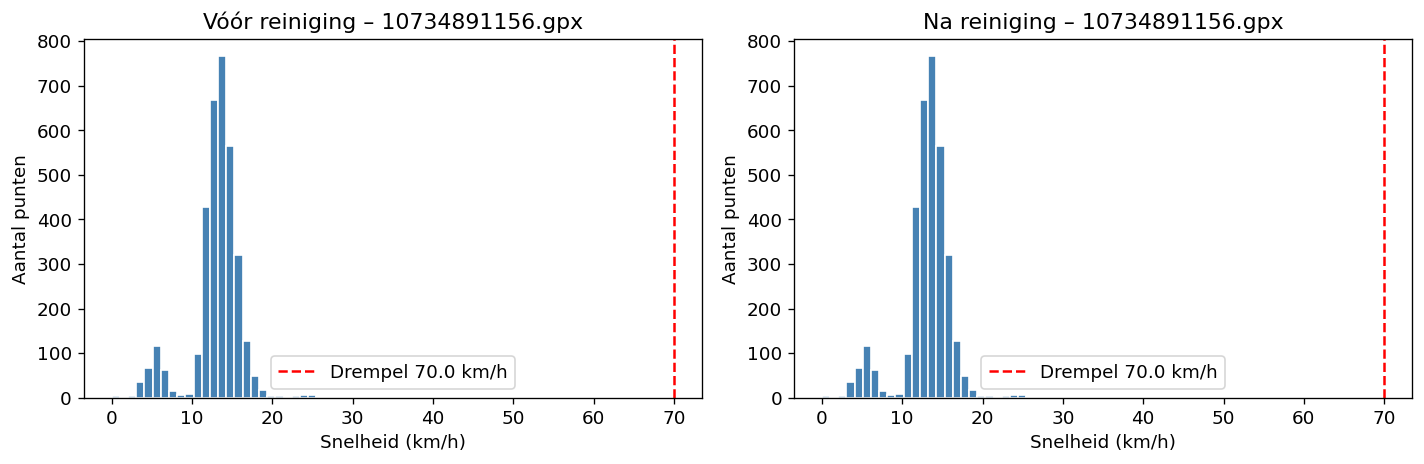

In [6]:
def controleer_en_reinig(df: pd.DataFrame, max_snelheid: float = MAX_SNELHEID_KMH) -> pd.DataFrame:
    """Detecteer en verwijder verdachte GPS-punten."""
    n_voor = len(df)
    bron = df['bron'].iloc[0]

    # ── 1. Tijdzone-check ──────────────────────────────────────────────────
    if df['timestamp'].dt.tz is None:
        print(f'{bron}: tijdstempels hebben geen tijdzone → UTC aangenomen')
        df['timestamp'] = df['timestamp'].dt.tz_localize('UTC')

    # Kolom met lokale tijd
    df['timestamp_lokaal'] = df['timestamp'].dt.tz_convert(LOCAL_TZ)
    print(f'{bron}: eerste punt UTC={df["timestamp"].iloc[0]}  '
          f'lokaal={df["timestamp_lokaal"].iloc[0]}')

    # ── 2. Dubbele tijdstempels ────────────────────────────────────────────
    n_dubbel = df.duplicated('timestamp').sum()
    if n_dubbel:
        print(f'{bron}: {n_dubbel} dubbele tijdstempels → verwijderd')
        df = df.drop_duplicates('timestamp')

    # ── 3. Ontbrekende GPS ─────────────────────────────────────────────────
    n_mis_gps = df['lat'].isna().sum()
    if n_mis_gps:
        print(f'  {bron}: {n_mis_gps} punten zonder GPS-coördinaten')

    # ── 4. Snelheidsoutliers ───────────────────────────────────────────────
    outlier_mask = df['snelheid_kmh'] > max_snelheid
    n_outlier = outlier_mask.sum()
    if n_outlier:
        print(f'{bron}: {n_outlier} punten met snelheid > {max_snelheid} km/h '
              f'(max gevonden: {df["snelheid_kmh"].max():.1f} km/h) → verwijderd')
        df = df[~outlier_mask]

    # ── 5. Negatief tijdsverschil ──────────────────────────────────────────
    df = df.sort_values('timestamp').reset_index(drop=True)
    n_achteruit = (df['tijd_s'] < 0).sum()
    if n_achteruit:
        print(f'{bron}: {n_achteruit} punten met negatief tijdsverschil → verwijderd')
        df = df[df['tijd_s'] >= 0]

    n_na = len(df)
    print(f'{bron}: {n_voor} → {n_na} punten ({n_voor - n_na} verwijderd)\n')
    return df.reset_index(drop=True)


activiteiten_schoon = [controleer_en_reinig(df) for df in activiteiten]

# Visualiseer snelheidsverdeling vóór/na reiniging (eerste activiteit)
if activiteiten and activiteiten_schoon:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, data, titel in zip(
        axes,
        [activiteiten[67], activiteiten_schoon[67]],
        ['Vóór reiniging', 'Na reiniging']
    ):
        v = data['snelheid_kmh'].dropna()
        ax.hist(v, bins=60, color='steelblue', edgecolor='white')
        ax.axvline(MAX_SNELHEID_KMH, color='red', linestyle='--', label=f'Drempel {MAX_SNELHEID_KMH} km/h')
        ax.set_xlabel('Snelheid (km/h)')
        ax.set_ylabel('Aantal punten')
        ax.set_title(f'{titel} – {data["bron"].iloc[0]}')
        ax.legend()
    plt.tight_layout()
    plt.show()

---
## Opdracht 3 – Bereken voor iedere acitivteit de totale afstand, totale duur en gemiddelde snelheid.

In [7]:
def activiteit_samenvatting(df: pd.DataFrame) -> dict:
    totaal_afstand_km = df['afstand_m'].sum() / 1000
    start    = df['timestamp'].min()
    eind     = df['timestamp'].max()
    duur_min = (eind - start).total_seconds() / 60
    gem_snelheid = totaal_afstand_km / (duur_min / 60) if duur_min > 0 else np.nan
    max_snelheid = df['snelheid_kmh'].max()

    # Hoogte: gebruik try/except om alle edge cases te vermijden
    hoogteverschil = np.nan
    try:
        h = df['hoogte'].dropna()
        if len(h) > 0:
            hoogteverschil = df['hoogte'].diff().clip(lower=0).sum()
    except (KeyError, TypeError):
        pass

    return {
        'bestand':          df['bron'].iloc[0],
        'sport':            df['sport'].iloc[0],
        'datum':            start.strftime('%Y-%m-%d'),
        'starttijd':        start.strftime('%H:%M:%S'),
        'afstand_km':       round(totaal_afstand_km, 2),
        'duur_min':         round(duur_min, 1),
        'gem_snelheid_kmh': round(gem_snelheid, 2),
        'max_snelheid_kmh': round(max_snelheid, 1),
        'hoogteklimmen_m':  round(hoogteverschil, 0) if not np.isnan(hoogteverschil) else np.nan,
        'n_punten':         len(df),
    }


samenvattingen = [activiteit_samenvatting(df) for df in activiteiten_schoon]
df_samen = pd.DataFrame(samenvattingen)

# Mooie weergave
styled = (df_samen.style
    .format({
        'afstand_km':       '{:.2f} km',
        'duur_min':         '{:.0f} min',
        'gem_snelheid_kmh': '{:.1f} km/h',
        'max_snelheid_kmh': '{:.1f} km/h',
        'hoogteklimmen_m':  '{:.0f} m',
    })
    .background_gradient(subset=['afstand_km', 'gem_snelheid_kmh'], cmap='Blues')
    .set_table_styles([{
        'selector': 'th',
        'props': [('position', 'sticky'), ('top', '0'), ('background', 'white'), ('z-index', '1')]
    }])
    .to_html()
)

# Scrollbare wrapper: 400px hoog, horizontaal en verticaal scrollbaar
display(HTML(f'''
    <div style="height:400px; overflow:auto; border:1px solid #ddd; border-radius:6px;">
        {styled}
    </div>
'''))

,bestand,sport,datum,starttijd,afstand_km,duur_min,gem_snelheid_kmh,max_snelheid_kmh,hoogteklimmen_m,n_punten
0,Ochtendloop.fit,running,2026-03-15,09:31:30,21.35 km,103 min,12.4 km/h,42.6 km/h,147 m,6185
1,Ochtendloop (2).fit,running,2025-03-09,09:31:49,21.38 km,99 min,13.0 km/h,21.5 km/h,87 m,5928
2,Middagloop.fit,running,2026-03-08,11:53:43,21.50 km,108 min,11.9 km/h,57.0 km/h,157 m,6450
3,Ochtendrit_schaatsen.fit,ice_skating,2025-02-28,07:04:44,2.86 km,53 min,3.2 km/h,41.0 km/h,0 m,3181
4,Schaatsen.fit,running,2025-03-14,06:54:54,20.24 km,58 min,21.1 km/h,48.0 km/h,11 m,3223
5,Ochtendloop (1).fit,running,2025-06-03,05:17:06,14.72 km,73 min,12.2 km/h,24.3 km/h,131 m,4321
6,Namiddagrit.fit,cycling,2025-06-07,13:51:28,40.70 km,100 min,24.4 km/h,38.4 km/h,325 m,1706
7,9188850181.fit,running,2023-06-02,13:30:51,1.97 km,58 min,2.0 km/h,29.2 km/h,438 m,3093
8,9319656749.fit,running,2023-06-23,12:20:05,1.68 km,70 min,1.4 km/h,39.7 km/h,723 m,3696
9,13581691410.gpx,running,2025-02-09,11:26:27,16.42 km,83 min,11.9 km/h,34.0 km/h,41 m,4956


---
## Opdracht 4 – Maak voor een activiteit een kaartje


In [8]:
def maak_kaart(df: pd.DataFrame, uitvoerpad: str = None) -> folium.Map:
    """Maak een interactieve Folium-kaart met de route en richting."""
    df_gps = df.dropna(subset=['lat', 'lon']).copy()
    if df_gps.empty:
        print('Geen GPS-data beschikbaar voor kaart.')
        return None

    # Centreerpunt
    midden_lat = df_gps['lat'].mean()
    midden_lon = df_gps['lon'].mean()

    kaart = folium.Map(
        location=[midden_lat, midden_lon],
        zoom_start=15,
        tiles='CartoDB positron'
    )

    # ── Kleurcodering op snelheid ──────────────────────────────────────────
    v = df_gps['snelheid_kmh'].fillna(0).clip(lower=0)
    v_max = v.quantile(0.95) if v.max() > 0 else 1
    norm  = mcolors.Normalize(vmin=0, vmax=v_max)
    cmap  = cm.get_cmap('RdYlGn')

    coördinaten = list(zip(df_gps['lat'], df_gps['lon']))

    # Segmenten met kleur op snelheid
    for i in range(1, len(df_gps)):
        snelheid = v.iloc[i]
        kleur = mcolors.to_hex(cmap(norm(snelheid)))
        folium.PolyLine(
            [coördinaten[i - 1], coördinaten[i]],
            color=kleur, weight=4, opacity=0.85,
            tooltip=f'{snelheid:.1f} km/h'
        ).add_to(kaart)

    # ── Richtingspijlen (elke 30 punten) ──────────────────────────────────
    stap = max(1, len(df_gps) // 40)
    for i in range(stap, len(df_gps), stap):
        lat1, lon1 = coördinaten[i - 1]
        lat2, lon2 = coördinaten[i]
        folium.RegularPolygonMarker(
            location=[(lat1 + lat2) / 2, (lon1 + lon2) / 2],
            number_of_sides=3,
            radius=6,
            rotation=np.degrees(np.arctan2(lon2 - lon1, lat2 - lat1)),
            color='navy', fill=True, fill_color='navy', fill_opacity=0.7,
            weight=1
        ).add_to(kaart)

    # ── Start- en eindmarker ───────────────────────────────────────────────
    folium.Marker(
        coördinaten[0],
        popup='<b>Start</b>',
        icon=folium.Icon(color='green', icon='play', prefix='fa')
    ).add_to(kaart)
    folium.Marker(
        coördinaten[-1],
        popup='<b>Finish</b>',
        icon=folium.Icon(color='red', icon='flag', prefix='fa')
    ).add_to(kaart)

    # Legenda
    legenda_html = f'''
    <div style="position:fixed;bottom:40px;left:40px;background:white;
         padding:10px 14px;border-radius:8px;box-shadow:2px 2px 6px rgba(0,0,0,.3);
         font-family:Arial;font-size:13px;z-index:9999">
      <b>{df_gps["bron"].iloc[0]}</b><br>
      <span style="color:red">■</span> Langzaam &nbsp;
      <span style="color:orange">■</span> Gemiddeld &nbsp;
      <span style="color:green">■</span> Snel<br>
      Max snelheid (p95): {v_max:.1f} km/h
    </div>'''
    kaart.get_root().html.add_child(folium.Element(legenda_html))

    if uitvoerpad:
        kaart.save(uitvoerpad)
        print(f'✅ Kaart opgeslagen: {uitvoerpad}')

    return kaart


# Maak kaart voor elke activiteit
df_keuze = activiteiten_schoon[0]

bron = df_keuze['bron'].iloc[0].replace('.fit', '').replace('.gpx', '')

kaart = maak_kaart(df_keuze, uitvoerpad=f'kaart_{bron}.html')

display(kaart)

# Toon laatste kaart inline in het notebook
if activiteiten_schoon:
    kaart = maak_kaart(activiteiten_schoon[-1])
    display(kaart)

✅ Kaart opgeslagen: kaart_Ochtendloop.html


---
##  Opdracht 5 – Maak een histogram van de gemiddelde snelheid voor alle activiteiten


Activiteiten per groep:


,bestand,sport,gem_snelheid_kmh,groep
0,Ochtendloop.fit,running,12.43,hardlopen
1,Ochtendloop (2).fit,running,12.99,hardlopen
2,Middagloop.fit,running,11.93,hardlopen
3,Ochtendrit_schaatsen.fit,ice_skating,3.24,zwemmen
4,Schaatsen.fit,running,21.13,hardlopen
...,...,...,...,...
563,5141444602.gpx,cycling,27.70,wielrennen
564,6039122967.gpx,running,13.84,hardlopen
565,4847729069.gpx,walking,5.87,wandelen
566,5603301690.gpx,cycling,29.27,wielrennen


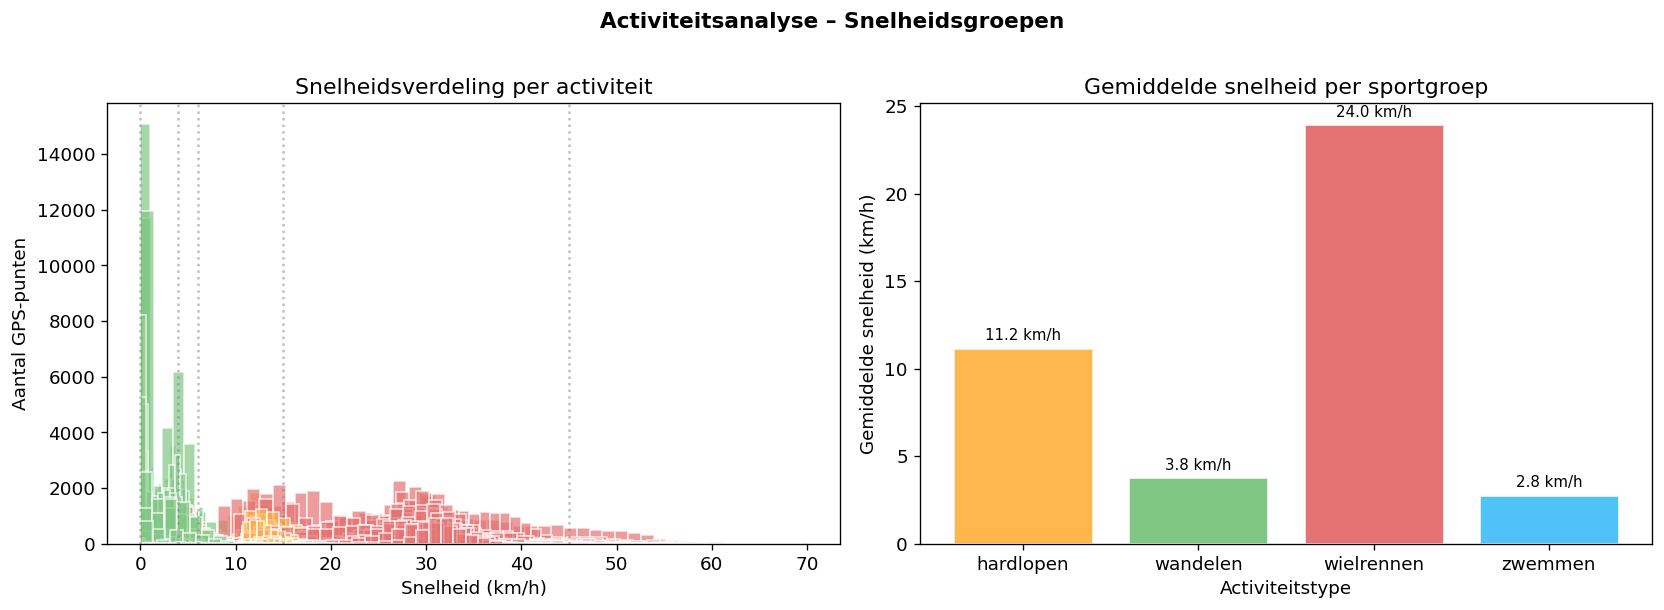

✅ Histogram opgeslagen als snelheid_histogram.png


In [ ]:
# ── Groepering op activiteitstype (op basis van snelheid + metadata) ────────
SNELHEID_GRENZEN = [
    (0,  4,   'zwemmen',    '#4FC3F7'),
    (4,  6,   'wandelen',   '#81C784'),
    (6,  15,  'hardlopen',  '#FFB74D'),
    (15, 45,  'wielrennen', '#E57373'),
    (45, 999, 'overig/auto','#CE93D8'),
]

def bepaal_groep(row):
    """Classificeer op basis van gemiddelde snelheid."""
    # Geef voorrang aan sporttype uit het bestand
    sport_raw = str(row.get('sport', '')).lower()
    mapping = {
        'running': 'hardlopen', 'run': 'hardlopen',
        'cycling': 'wielrennen', 'ride': 'wielrennen', 'biking': 'wielrennen',
        'swimming': 'zwemmen', 'swim': 'zwemmen',
        'walking': 'wandelen', 'hike': 'wandelen', 'hiking': 'wandelen',
    }
    for sleutel, groep in mapping.items():
        if sleutel in sport_raw:
            return groep

    # Terugval: snelheidsindeling
    v = row.get('gem_snelheid_kmh', np.nan)
    if pd.isna(v):
        return 'onbekend'
    for v_min, v_max, groep, _ in SNELHEID_GRENZEN:
        if v_min <= v < v_max:
            return groep
    return 'onbekend'


df_samen['groep'] = df_samen.apply(bepaal_groep, axis=1)

print('Activiteiten per groep:')
display(df_samen[['bestand', 'sport', 'gem_snelheid_kmh', 'groep']])


# ── Plot 1: Histogram punt-snelheden voor alle activiteiten ─────────────────
KLEUR_MAP = {
    'zwemmen':    '#4FC3F7',
    'wandelen':   '#81C784',
    'hardlopen':  '#FFB74D',
    'wielrennen': '#E57373',
    'overig/auto':'#CE93D8',
    'onbekend':   '#BDBDBD',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Links: per activiteit, gekleurd per groep
ax = axes[0]
for df, info in zip(activiteiten_schoon, samenvattingen):
    groep = df_samen.loc[df_samen['bestand'] == info['bestand'], 'groep'].values[0]
    kleur = KLEUR_MAP.get(groep, '#BDBDBD')
    v = df['snelheid_kmh'].dropna()
    v = v[v < MAX_SNELHEID_KMH]
    ax.hist(v, bins=50, alpha=0.7, color=kleur, edgecolor='white',
            label=f'{info["bestand"]} ({groep})')
ax.set_xlabel('Snelheid (km/h)')
ax.set_ylabel('Aantal GPS-punten')
ax.set_title('Snelheidsverdeling per activiteit')

# Voeg grenzen toe als verticale lijnen
for v_min, v_max, groep, kleur in SNELHEID_GRENZEN:
    ax.axvline(v_min, color='gray', linestyle=':', alpha=0.5)

# Rechts: gemiddelde snelheid per groep (barplot)
ax2 = axes[1]
groep_stats = df_samen.groupby('groep')['gem_snelheid_kmh'].mean().reset_index()
kleuren = [KLEUR_MAP.get(g, '#BDBDBD') for g in groep_stats['groep']]
bars = ax2.bar(groep_stats['groep'], groep_stats['gem_snelheid_kmh'],
               color=kleuren, edgecolor='white', linewidth=1.5)
ax2.bar_label(bars, fmt='%.1f km/h', padding=3, fontsize=9)
ax2.set_ylabel('Gemiddelde snelheid (km/h)')
ax2.set_xlabel('Activiteitstype')
ax2.set_title('Gemiddelde snelheid per sportgroep')

plt.suptitle('Activiteitsanalyse – Snelheidsgroepen', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('snelheid_histogram.png', bbox_inches='tight', dpi=150)
plt.show()
print('Histogram opgeslagen als snelheid_histogram.png')